In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df =pd.read_csv("Customer_Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


##  Data Understanding and Initial Inspection

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

## Dataset Columns Description

The dataset contains **7,043 customers** and **21 columns**.

| Column | Description |
|---|---|
| `customerID` | A unique identification number for each customer. |
| `gender` | The customer's gender: Male or Female. |
| `SeniorCitizen` | Indicates whether the customer is a senior citizen: 1 = Yes, 0 = No. |
| `Partner` | Indicates whether the customer has a partner: Yes or No. |
| `Dependents` | Indicates whether the customer has dependents: Yes or No. |
| `tenure` | The number of months the customer has stayed with the company. |
| `PhoneService` | Indicates whether the customer has phone service. |
| `MultipleLines` | Indicates whether the customer has multiple phone lines. |
| `InternetService` | The customer's internet service type: DSL, Fiber optic, or No internet service. |
| `OnlineSecurity` | Indicates whether the customer has an online security service. |
| `OnlineBackup` | Indicates whether the customer has an online backup service. |
| `DeviceProtection` | Indicates whether the customer has a device protection service. |
| `TechSupport` | Indicates whether the customer has technical support. |
| `StreamingTV` | Indicates whether the customer uses a TV streaming service. |
| `StreamingMovies` | Indicates whether the customer uses a movie streaming service. |
| `Contract` | The customer's contract type: Month-to-month, One year, or Two year. |
| `PaperlessBilling` | Indicates whether the customer uses paperless billing. |
| `PaymentMethod` | The payment method used by the customer. |
| `MonthlyCharges` | The amount charged to the customer each month. |
| `TotalCharges` | The total amount charged to the customer during their entire subscription. |
| `Churn` | The target column. It indicates whether the customer left the company: Yes or No. |

### Important Notes

- `Churn` is the **target variable** that the model will predict.
- `customerID` is only an identifier and will not help the model learn, so it will be removed before training.
- `TotalCharges` should be numeric, but its current data type is `str`. We will investigate and convert it during data cleaning.
- `SeniorCitizen` is stored as an integer, but it represents a categorical Yes/No value.
- `tenure`, `MonthlyCharges`, and `TotalCharges` are the main numerical features.

In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [8]:
df.groupby("Churn")["MonthlyCharges"].mean()

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

In [9]:
categorical_cols=df.select_dtypes(include="str").columns
for col in categorical_cols:
    print(col)
    print(df[col].unique())
    print("-"*50)

customerID
<ArrowStringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU',
 ...
 '9767-FFLEM', '0639-TSIQW', '8456-QDAVC', '7750-EYXWZ', '2569-WGERO',
 '6840-RESVB', '2234-XADUH', '4801-JZAZL', '8361-LTMKD', '3186-AJIEK']
Length: 7043, dtype: str
--------------------------------------------------
gender
<ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str
--------------------------------------------------
Partner
<ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str
--------------------------------------------------
Dependents
<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
--------------------------------------------------
PhoneService
<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
--------------------------------------------------
MultipleLines
<ArrowStringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
------------------------------------------------

##  Data Cleaning

In [10]:
column_summary=pd.DataFrame({
    'dtype':df.dtypes,
    'missing_values':df.isna().sum(),
    'unique_values':df.nunique()
})
column_summary

,dtype,missing_values,unique_values
customerID,str,0,7043
gender,str,0,2
SeniorCitizen,int64,0,2
Partner,str,0,2
Dependents,str,0,2
tenure,int64,0,73
PhoneService,str,0,2
MultipleLines,str,0,3
InternetService,str,0,3
OnlineSecurity,str,0,3


In [11]:
df["customerID"].duplicated().sum()

np.int64(0)

In [12]:
df["SeniorCitizen"].unique()

array([0, 1])

In [13]:
pd.to_numeric(df["TotalCharges"],errors='coerce').isna().sum()

np.int64(11)

In [14]:
df["TotalCharges"]=pd.to_numeric(df["TotalCharges"],errors="coerce")

In [15]:
df["TotalCharges"].isna().sum()

np.int64(11)

In [16]:
df[df["TotalCharges"].isna()][["tenure", "MonthlyCharges", "TotalCharges"]]

,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
3331,0,19.85,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
5218,0,19.70,NaN
6670,0,73.35,NaN


In [17]:
df["TotalCharges"]=df["TotalCharges"].fillna(0)
df["TotalCharges"].isna().sum()

np.int64(0)

### Handling Missing Values in TotalCharges

`TotalCharges` contained 11 blank values that became `NaN` after converting the column to numeric.

All affected customers have `tenure = 0`, indicating that they are new customers who have not completed their first billing period.

Therefore, the missing `TotalCharges` values were replaced with `0`.

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df.drop(columns="customerID").duplicated().sum()

np.int64(22)

In [20]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [21]:
print("Negative tenure:", (df["tenure"] < 0).sum())
print("Negative monthly charges:", (df["MonthlyCharges"] < 0).sum())
print("Negative total charges:", (df["TotalCharges"] < 0).sum())

Negative tenure: 0
Negative monthly charges: 0
Negative total charges: 0


In [22]:
print("Dataset shape:", df.shape)
print("Duplicated rows:", df.duplicated().sum())
print("Missing values:", df.isna().sum().sum())

df.info()

Dataset shape: (7043, 21)
Duplicated rows: 0
Missing values: 0
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str

## Exploratory Data Analysis (EDA)

In [23]:
churn_counts=df["Churn"].value_counts()
churn_percentages=df["Churn"].value_counts(normalize=True)*100
churn_dist=pd.DataFrame({
    "Counts":churn_counts,
    "percentage":churn_percentages.round(2)
})
churn_dist

,Counts,percentage
Churn,,
No,5174,73.46
Yes,1869,26.54


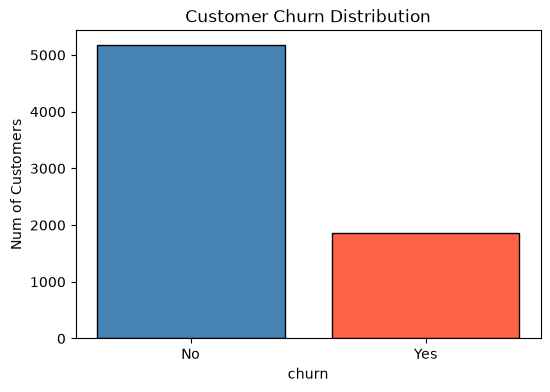

In [24]:
plt.figure(figsize=(6,4))
plt.bar(churn_counts.index,churn_counts.values,color=["steelblue","tomato"],edgecolor="black")
plt.title("Customer Churn Distribution")
plt.xlabel("churn")
plt.ylabel("Num of Customers")
plt.show()

### Observation

Most customers did not leave the company. Approximately 26.5% of customers churned, while 73.5% stayed.

The target is moderately imbalanced, so accuracy alone may not be sufficient for evaluating the model. Recall, F1-score, and ROC-AUC should also be considered.

In [25]:
contract_churn=pd.crosstab(
    df["Contract"],df["Churn"],normalize="index"
)*100
contract_churn=contract_churn.round(2)
contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


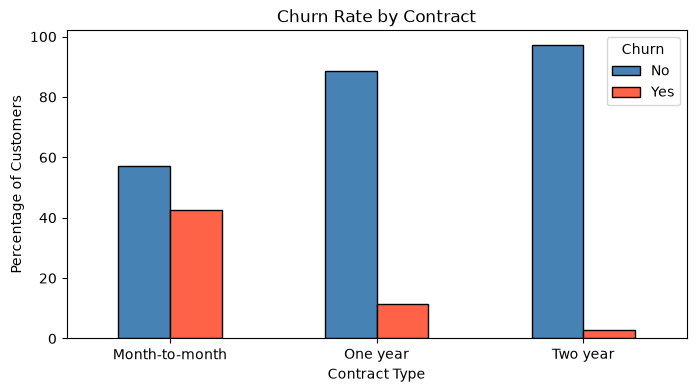

In [26]:
contract_churn.plot(
    kind="bar",
    figsize=(8,4),
    color=["steelblue","tomato"],
    edgecolor="black"
)
plt.title("Churn Rate by Contract")
plt.xlabel("Contract Type")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

In [27]:
tenure_smmary=df.groupby("Churn")["tenure"].agg(["count","mean","min","max","median"])
tenure_smmary

,count,mean,min,max,median
Churn,,,,,
No,5174,37.569965,0,72,38.0
Yes,1869,17.979133,1,72,10.0


<Figure size 700x500 with 0 Axes>

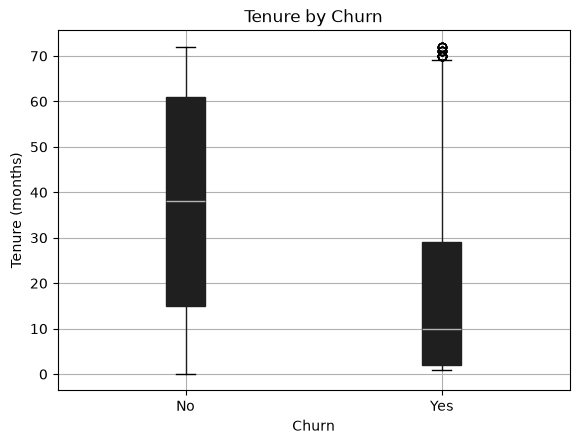

In [28]:
plt.figure(figsize=(7,5))
df.boxplot(column="tenure", by="Churn",patch_artist=True)
plt.title("Tenure by Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Tenure (months)")
plt.show()

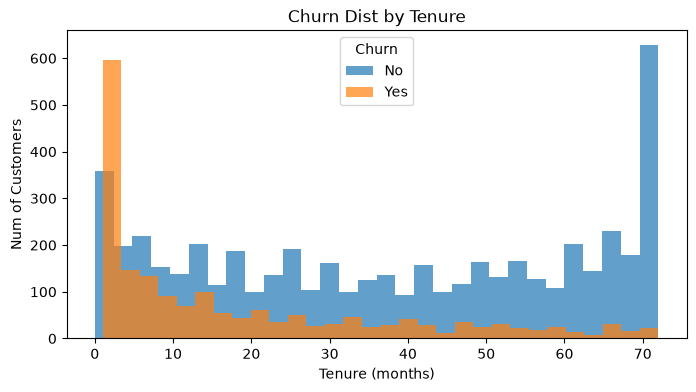

In [29]:
plt.figure(figsize=(8,4))
plt.hist(
    df[df["Churn"]=="No"]["tenure"],
    bins=30, alpha=0.7, label="No"
)
plt.hist(
    df[df["Churn"]=="Yes"]["tenure"],
    bins=30, alpha=0.7, label="Yes"
)
plt.title("Churn Dist by Tenure")
plt.xlabel("Tenure (months)")
plt.ylabel("Num of Customers")
plt.legend(title="Churn")
plt.show()

In [30]:
numeric_cols=["tenure", "MonthlyCharges", "TotalCharges"]
df.groupby("Churn")[numeric_cols].mean().round(2)

,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,37.57,61.27,2549.91
Yes,17.98,74.44,1531.80


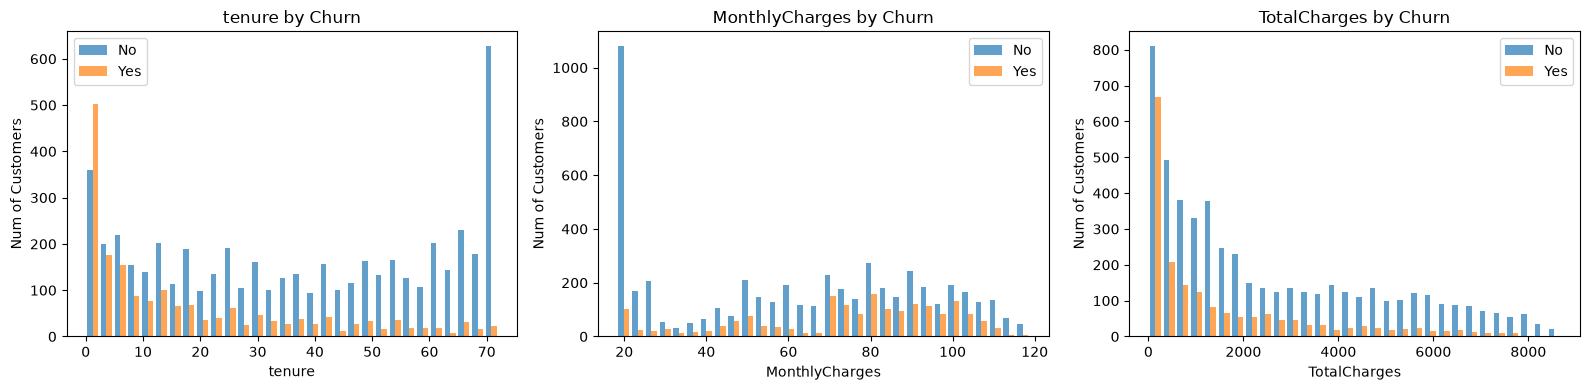

In [31]:
fig,axes=plt.subplots(1,3,figsize=(16,4))
for i,col in enumerate(numeric_cols):
        axes[i].hist(
            [
                df[df["Churn"] == "No"][col],
                df[df["Churn"] == "Yes"][col]
            ],
            bins=30,
            label=["No", "Yes"],
            alpha=0.7
        )
        axes[i].set_title(f"{col} by Churn")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Num of Customers")
        axes[i].legend()
plt.tight_layout()
plt.show()

### Numerical Features Insights

- Customers who churned are concentrated in the early months of their subscription, suggesting that new customers have a higher churn risk.
- Customers with long tenure are more likely to remain with the company.
- Churned customers tend to have moderate to high monthly charges, suggesting that higher monthly costs may be associated with churn.
- Most churned customers have low total charges because they usually leave during the early months of their subscription.
- Low `TotalCharges` should not be interpreted as a direct cause of churn because it is strongly influenced by `tenure`.

In [32]:
InternetService_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

InternetService_churn

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


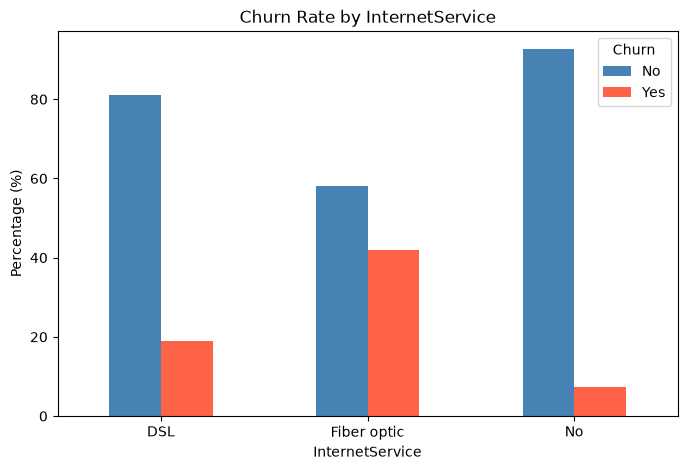

In [33]:
InternetService_churn.plot(
    kind="bar",
    figsize=(8, 5),
    color=["steelblue", "tomato"]
)

plt.title("Churn Rate by InternetService")
plt.xlabel("InternetService")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

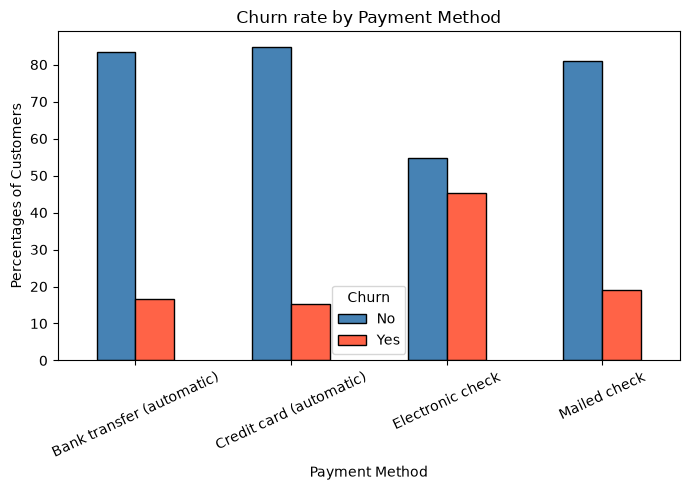

In [34]:
payment_churn=pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],normalize="index"
)*100
payment_churn=payment_churn.round(2)
payment_churn.plot(
    kind="bar",
    figsize=(7,5),
    color=["steelblue","tomato"],
    edgecolor="black"
)
plt.title("Churn rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Percentages of Customers")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

In [35]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

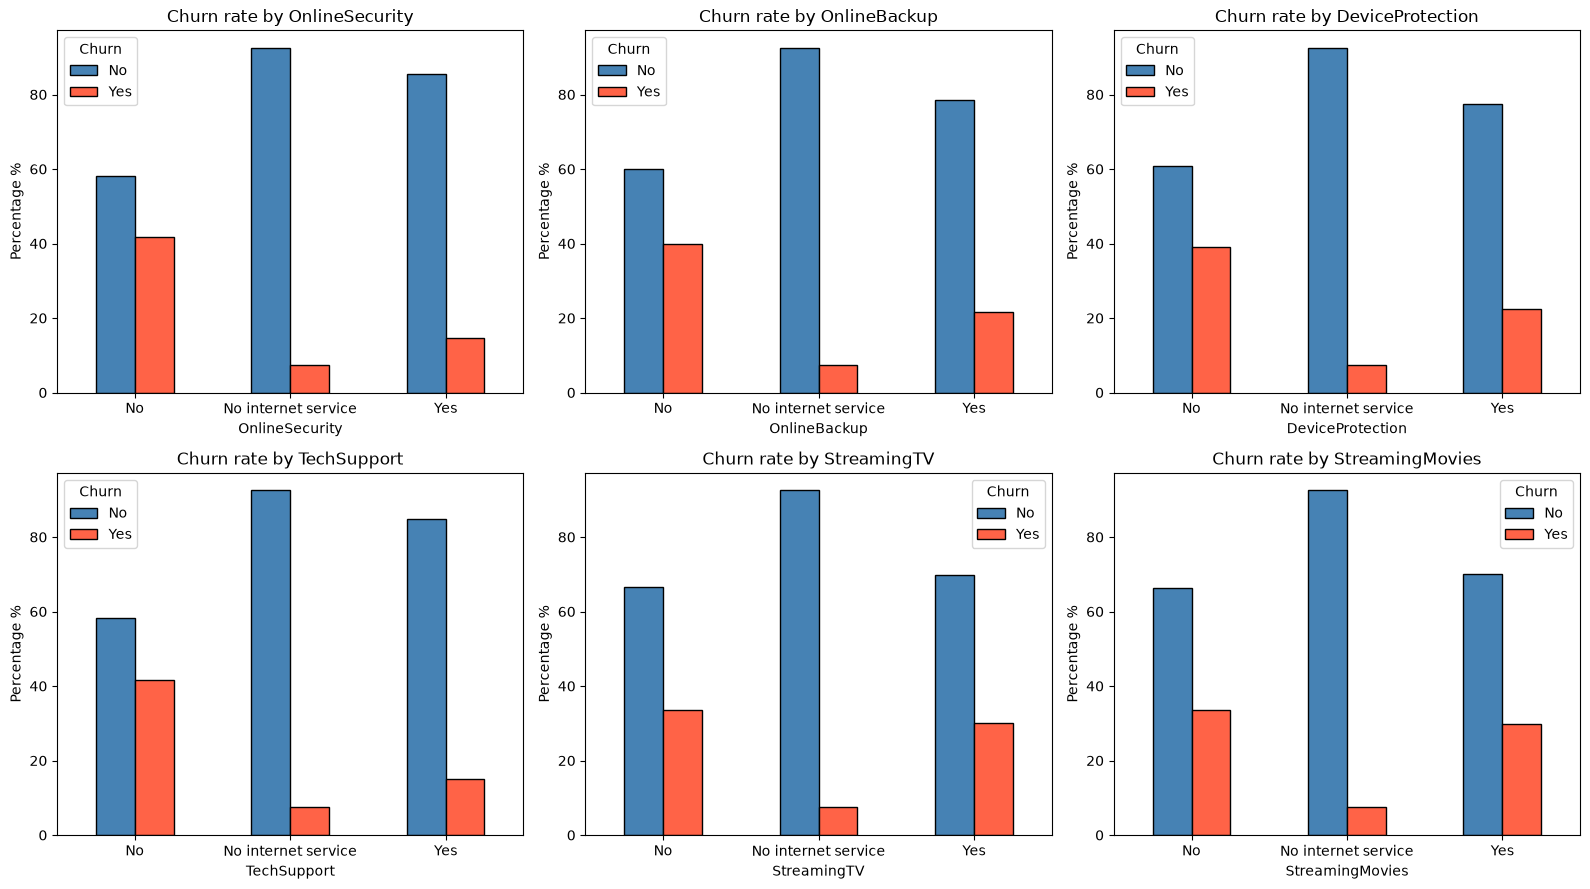

In [36]:
service_cols = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]
fig,axes=plt.subplots(2,3,figsize=(16,9))
axes=axes.flatten()
for i, col in enumerate(service_cols):
    churn_rate=pd.crosstab(
        df[col],
        df["Churn"],
        normalize="index"
    )*100
    churn_rate.plot(
        kind="bar",
        color=["steelblue","tomato"],
        ax=axes[i],
        edgecolor="black"
    )
    axes[i].set_title(f"Churn rate by {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Percentage %")
    axes[i].legend(title="Churn")
    axes[i].tick_params(axis="x",rotation=0)
plt.tight_layout()
plt.show()

    

In [37]:
corr_df = df[
    ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]
].copy()
corr_df["Churn"]=df["Churn"].map({
    "Yes":1,
    "No":0
})
correlation_matrix=corr_df.corr().round(2)
correlation_matrix

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
SeniorCitizen,1.00,0.02,0.22,0.10,0.15
tenure,0.02,1.00,0.25,0.83,-0.35
MonthlyCharges,0.22,0.25,1.00,0.65,0.19
TotalCharges,0.10,0.83,0.65,1.00,-0.20
Churn,0.15,-0.35,0.19,-0.20,1.00


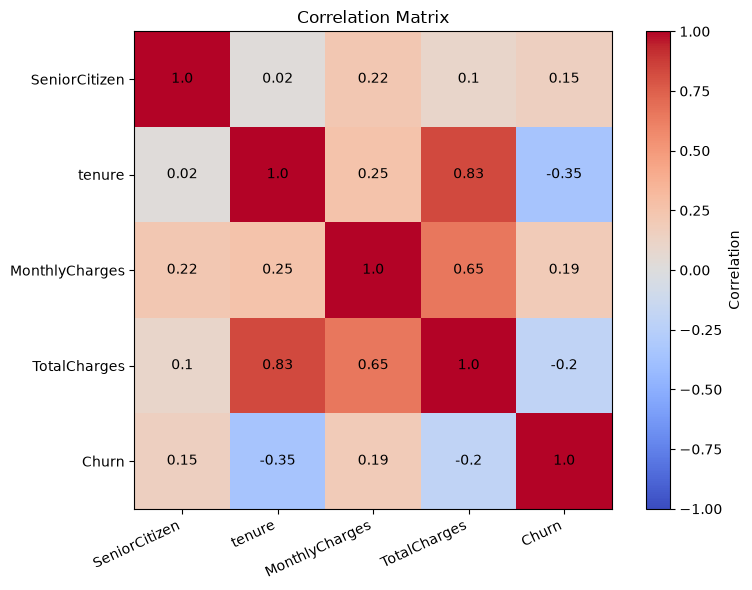

In [38]:
plt.figure(figsize=(8,6))
plt.imshow(
    correlation_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=+1
)
plt.colorbar(label="Correlation")
plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=25,
    ha="right"
)
plt.yticks(
    range(len(correlation_matrix.index)),
    correlation_matrix.index
)
for i in range(len(correlation_matrix.index)):
    for j in range(len(correlation_matrix.columns)):
        plt.text(
            j,# j: column → x
            i, # i: row → y
            correlation_matrix.iloc[i,j],
            ha="center",va="center"
        )
plt.title("Correlation Matrix") 
plt.tight_layout()
plt.show()

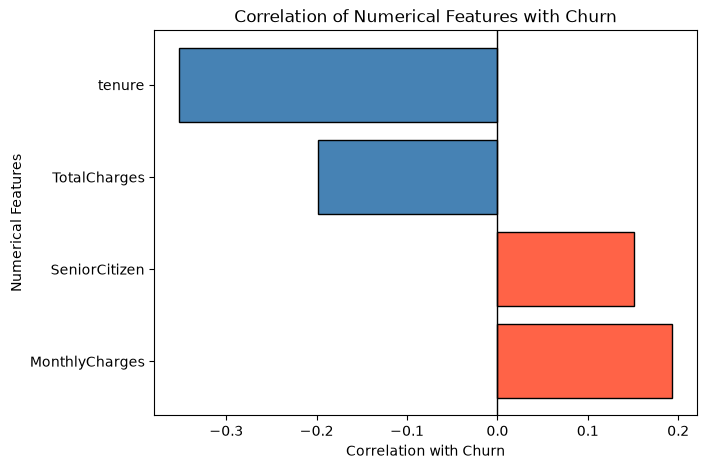

In [39]:
target_correlation=(
    corr_df.corr()["Churn"].drop("Churn").sort_values(ascending=False)
)
colors=[
    "tomato" if value>0 else "steelblue"
    for value in target_correlation
]

plt.figure(figsize=(7,5))
plt.barh(
    target_correlation.index,
    target_correlation.values,
    color=colors,
    edgecolor="black"
    
)
plt.axvline(0,color="black",linewidth=1)
plt.xlabel("Correlation with Churn")
plt.ylabel("Numerical Features")
plt.title("Correlation of Numerical Features with Churn")
plt.show()

## EDA Summary

- The dataset has a moderately imbalanced target: 26.54% of customers churned.
- Month-to-month customers have the highest churn rate, while two-year contracts have the lowest.
- Customers with short tenure are considerably more likely to churn.
- Fiber optic customers have a higher churn rate than DSL customers.
- Higher monthly charges are weakly associated with increased churn.
- Total charges are strongly related to tenure because they accumulate over time.
- Customers without online security or technical support show higher churn rates.
- The company should focus its retention efforts on new customers, especially those with month-to-month contracts and higher monthly charges.

## Define Features and Target

In [40]:
customer_ids=df["customerID"].copy()
X=df.drop(columns=["customerID", "Churn"])
y=df["Churn"].map({
    "Yes":1,
    "No":0
})
print("X shape:", X.shape)
print("y shape:", y.shape)
print("\ny values:")
print(y.value_counts())

X shape: (7043, 19)
y shape: (7043,)

y values:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [41]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test,id_train,id_test=train_test_split(
    X,y,customer_ids, test_size=0.2,
    random_state=42, stratify=y
)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nTrain churn percentage:")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTest churn percentage:")
print((y_test.value_counts(normalize=True) * 100).round(2))

X_train shape: (5634, 19)
X_test shape: (1409, 19)

Train churn percentage:
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64

Test churn percentage:
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64


In [42]:
numerical_cols=X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols=X_train.select_dtypes(include="str").columns.tolist()


print("Numerical columns:")
print(numerical_cols)

print("\nCategorical columns:")
print(categorical_cols)

print("\nNumber of numerical columns:", len(numerical_cols))
print("Number of categorical columns:", len(categorical_cols))

Numerical columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical columns:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Number of numerical columns: 4
Number of categorical columns: 15


In [43]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

numerical_pipeline=Pipeline(steps=[
    ("imputer",SimpleImputer(strategy="median")),
    ("scaler",StandardScaler())
])
categorical_pipeline=Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline, numerical_cols),
        ("cat", categorical_pipeline, categorical_cols)
    ]
)

In [44]:
from sklearn.linear_model import LogisticRegression
logistic_pipeline=Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model",LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
    
])
logistic_pipeline.fit(X_train,y_train)



,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pa

In [45]:
y_pred_train_log=logistic_pipeline.predict(X_train)
y_pred_test_log=logistic_pipeline.predict(X_test)

y_proba_train_log=logistic_pipeline.predict_proba(X_train)[:,1]
y_proba_test_log=logistic_pipeline.predict_proba(X_test)[:,1]


In [46]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay
)

accuracy_log_train=accuracy_score(y_train,y_pred_train_log)
roc_auc_log_train=roc_auc_score(y_train,y_proba_train_log)

accuracy_log_test=accuracy_score(y_test,y_pred_test_log)
roc_auc_log_test=roc_auc_score(y_test,y_proba_test_log)

print("Logistic Regression Test Results")
print("-" * 35)
print("Accuracy:", round(accuracy_log_test, 4))
print("ROC-AUC:", round(roc_auc_log_test, 4))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_test_log,
    target_names=["No Churn", "Churn"]
))

print("Logistic Regression Train Results")
print("-" * 35)
print("Accuracy:", round(accuracy_log_train, 4))
print("ROC-AUC:", round(roc_auc_log_train, 4))

print("\nClassification Report:")
print(classification_report(
    y_train,
    y_pred_train_log,
    target_names=["No Churn", "Churn"]
))

Logistic Regression Test Results
-----------------------------------
Accuracy: 0.7381
ROC-AUC: 0.8416

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

Logistic Regression Train Results
-----------------------------------
Accuracy: 0.7528
ROC-AUC: 0.8492

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.91      0.73      0.81      4139
       Churn       0.52      0.81      0.63      1495

    accuracy                           0.75      5634
   macro avg       0.72      0.77      0.72      5634
weighted avg       0.81      0.75      0.77      5634



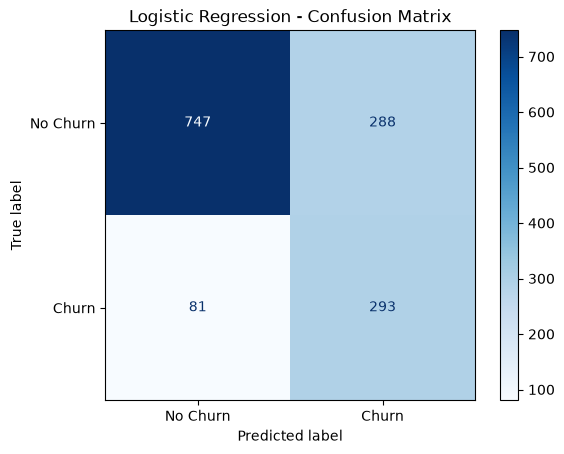

In [47]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_test_log,
    display_labels=["No Churn", "Churn"],
    cmap="Blues"
)

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

### Logistic Regression Results

- The model achieved a test ROC-AUC of 0.8416, indicating good ability to rank high-risk customers.
- It identified 78% of customers who actually churned.
- Churn precision was 50%, meaning that approximately half of the churn alerts were correct.
- The similar train and test results indicate that there is no clear overfitting.
- Using balanced class weights improved attention to churned customers, with the trade-off of producing more false-positive alerts.

##  Random Forest Training and Evaluation

### Untuned Random Forest

In [48]:
from sklearn.ensemble import RandomForestClassifier
random_forest_pipeline=Pipeline(steps=[
    ("preprocessor",preprocessor),
    ("model",RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
        
    ))
])
random_forest_pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pa

In [49]:
y_pred_train_rf = random_forest_pipeline.predict(X_train)
y_pred_test_rf = random_forest_pipeline.predict(X_test)

y_proba_train_rf = random_forest_pipeline.predict_proba(X_train)[:, 1]
y_proba_test_rf = random_forest_pipeline.predict_proba(X_test)[:, 1]


In [50]:
accuracy_rf_train=accuracy_score(y_train,y_pred_train_rf)
roc_auc_rf_train=roc_auc_score(y_train,y_proba_train_rf)

accuracy_rf_test=accuracy_score(y_test,y_pred_test_rf)
roc_auc_rf_test=roc_auc_score(y_test,y_proba_test_rf)

print("Random Forest Classifier Test Results")
print("-" * 35)
print("Accuracy:", round(accuracy_rf_test, 4))
print("ROC-AUC:", round(roc_auc_rf_test, 4))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_test_rf,
    target_names=["No Churn", "Churn"]
))

print("Random Forest Classifier Train Results")
print("-" * 35)
print("Accuracy:", round(accuracy_rf_train, 4))
print("ROC-AUC:", round(roc_auc_rf_train, 4))

print("\nClassification Report:")
print(classification_report(
    y_train,
    y_pred_train_rf,
    target_names=["No Churn", "Churn"]
))

Random Forest Classifier Test Results
-----------------------------------
Accuracy: 0.7693
ROC-AUC: 0.8218

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.86      0.82      0.84      1035
       Churn       0.56      0.64      0.59       374

    accuracy                           0.77      1409
   macro avg       0.71      0.73      0.72      1409
weighted avg       0.78      0.77      0.77      1409

Random Forest Classifier Train Results
-----------------------------------
Accuracy: 0.9945
ROC-AUC: 1.0

Classification Report:
              precision    recall  f1-score   support

    No Churn       1.00      0.99      1.00      4139
       Churn       0.98      1.00      0.99      1495

    accuracy                           0.99      5634
   macro avg       0.99      1.00      0.99      5634
weighted avg       0.99      0.99      0.99      5634



### Random Forest Results

- Random Forest achieved nearly perfect training performance but performed considerably worse on the test data.
- The large gap between train and test results indicates strong overfitting.
- Although its test accuracy was higher than Logistic Regression, its churn recall, F1-score, and ROC-AUC were lower.
- Therefore, accuracy alone would incorrectly suggest that Random Forest is the better model.
- Tree depth and minimum sample constraints should be tuned to reduce overfitting.

## 8. Cross-Validation

Cross-validation evaluates each model on multiple training and validation splits.  
The test set remains untouched for the final evaluation.

In [51]:
from sklearn.model_selection import StratifiedKFold,cross_validate
cv=StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}
cv_logistic=cross_validate(
    logistic_pipeline,
    X_train, y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)
cv_logistic_df = pd.DataFrame(cv_logistic)
cv_logistic_df

,fit_time,score_time,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
0,0.086662,0.033273,0.767524,0.540481,0.826087,0.653439,0.847111
1,0.087129,0.034593,0.724933,0.487965,0.745819,0.589947,0.825451
2,0.089951,0.034247,0.737356,0.503158,0.799331,0.617571,0.841561
3,0.088243,0.034494,0.755102,0.523517,0.856187,0.649746,0.862688
4,0.091445,0.033690,0.757549,0.529545,0.779264,0.630582,0.852952


In [52]:
cv_logistic_df.mean().round(4)

fit_time          0.0887
score_time        0.0341
test_accuracy     0.7485
test_precision    0.5169
test_recall       0.8013
test_f1           0.6283
test_roc_auc      0.8460
dtype: float64

In [53]:
cv_rf=cross_validate(
    random_forest_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
    
)
cv_rf_df = pd.DataFrame(cv_rf)
cv_rf_df

,fit_time,score_time,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
0,0.949589,0.151591,0.775510,0.566860,0.652174,0.606532,0.817552
1,0.981211,0.164043,0.748004,0.523077,0.568562,0.544872,0.808213
2,1.024697,0.184302,0.785271,0.582609,0.672241,0.624224,0.827684
3,0.597802,0.145647,0.779947,0.575668,0.648829,0.610063,0.818162
4,1.095782,0.152377,0.782416,0.580838,0.648829,0.612954,0.840199


In [54]:
cv_rf_df.mean().round(4)

fit_time          0.9298
score_time        0.1596
test_accuracy     0.7742
test_precision    0.5658
test_recall       0.6381
test_f1           0.5997
test_roc_auc      0.8224
dtype: float64

In [55]:
cv_comparison=pd.DataFrame({
    "Logistic Regression":cv_logistic_df[["test_accuracy",
                                          "test_precision",
                                          "test_recall",
                                          "test_f1",
                                          "test_roc_auc"]].mean().round(4),
    "Random Forest": cv_rf_df[["test_accuracy",
                                "test_precision",
                                "test_recall",
                                "test_f1",
                                "test_roc_auc"]].mean().round(4)
})
cv_comparison

,Logistic Regression,Random Forest
test_accuracy,0.7485,0.7742
test_precision,0.5169,0.5658
test_recall,0.8013,0.6381
test_f1,0.6283,0.5997
test_roc_auc,0.8460,0.8224


### Cross-Validation Model Comparison

Random Forest achieved higher accuracy and precision. However, Logistic Regression achieved considerably higher churn recall, F1-score, and ROC-AUC.

Because the main business objective is to identify customers at risk of leaving, missing a churned customer is generally more costly than contacting a customer who would have stayed.

Therefore, Logistic Regression is currently the preferred model:

- Churn Recall: 80.13%
- Churn F1-score: 62.83%
- ROC-AUC: 84.60%

The model provides better churn detection and more stable generalization than the untuned Random Forest.

###  Hyperparameter Tuning and Overfitting Reduction

In [56]:
from sklearn.model_selection import RandomizedSearchCV
rf_param_distributions={"model__n_estimators": [200, 300, 500],
    "model__max_depth": [5, 8, 12, None],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 5, 10],
    "model__max_features": ["sqrt", "log2"]
}
rf_random_search=RandomizedSearchCV(
    estimator=random_forest_pipeline,
    param_distributions=rf_param_distributions,
    n_iter=20,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
rf_random_search.fit(X_train,y_train)


Fitting 5 folds for each of 20 candidates, totalling 100 fits


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': [5, 8, ...], 'model__max_features': ['sqrt', 'log2'], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best e

In [57]:
rf_random_search.best_score_.round(4)

np.float64(0.6363)

In [58]:
rf_random_search.best_params_

{'model__n_estimators': 500,
 'model__min_samples_split': 2,
 'model__min_samples_leaf': 2,
 'model__max_features': 'sqrt',
 'model__max_depth': 8}

In [59]:
best_rf_pipeline=rf_random_search.best_estimator_
y_pred_train_rf_tuned = best_rf_pipeline.predict(X_train)
y_pred_test_rf_tuned = best_rf_pipeline.predict(X_test)

y_proba_train_rf_tuned = best_rf_pipeline.predict_proba(X_train)[:, 1]
y_proba_test_rf_tuned = best_rf_pipeline.predict_proba(X_test)[:, 1]

In [60]:
accuracy_rf_tuned_train = accuracy_score(
    y_train,
    y_pred_train_rf_tuned
)

roc_auc_rf_tuned_train = roc_auc_score(
    y_train,
    y_proba_train_rf_tuned
)

accuracy_rf_tuned_test = accuracy_score(
    y_test,
    y_pred_test_rf_tuned
)

roc_auc_rf_tuned_test = roc_auc_score(
    y_test,
    y_proba_test_rf_tuned
)

In [61]:
print("Tuned Random Forest Test Results")
print("-" * 35)

print("Accuracy:", round(accuracy_rf_tuned_test, 4))
print("ROC-AUC:", round(roc_auc_rf_tuned_test, 4))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_test_rf_tuned,
    target_names=["No Churn", "Churn"]
))

print("Tuned Random Forest Train Results")
print("-" * 35)

print("Accuracy:", round(accuracy_rf_tuned_train, 4))
print("ROC-AUC:", round(roc_auc_rf_tuned_train, 4))

print("\nClassification Report:")
print(classification_report(
    y_train,
    y_pred_train_rf_tuned,
    target_names=["No Churn", "Churn"]
))

Tuned Random Forest Test Results
-----------------------------------
Accuracy: 0.7509
ROC-AUC: 0.8409

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.91      0.74      0.81      1035
       Churn       0.52      0.79      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.81      0.75      0.76      1409

Tuned Random Forest Train Results
-----------------------------------
Accuracy: 0.7973
ROC-AUC: 0.9023

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.95      0.77      0.85      4139
       Churn       0.58      0.88      0.70      1495

    accuracy                           0.80      5634
   macro avg       0.76      0.82      0.77      5634
weighted avg       0.85      0.80      0.81      5634



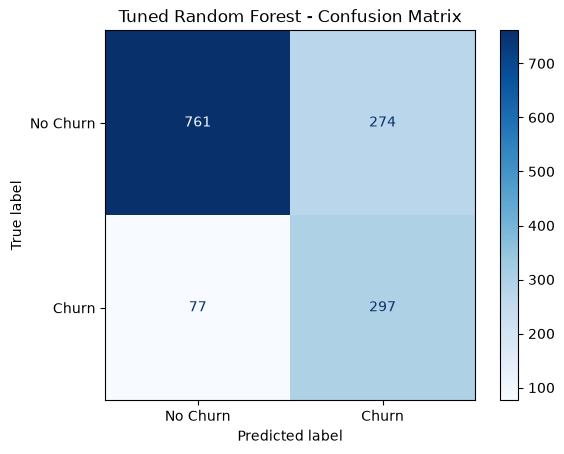

In [62]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_test_rf_tuned,
    display_labels=["No Churn", "Churn"],
    cmap="Blues"
)

plt.title("Tuned Random Forest - Confusion Matrix")
plt.show()

In [63]:
cv_rf_tuned = cross_validate(
    best_rf_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

cv_rf_tuned_df = pd.DataFrame(cv_rf_tuned)
cv_rf_tuned_df.mean().round(2)

fit_time          1.57
score_time        0.31
test_accuracy     0.76
test_precision    0.53
test_recall       0.79
test_f1           0.64
test_roc_auc      0.85
dtype: float64

##  XGBoost Model

### Handling Class Imbalance

In [64]:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

scale_pos_weight.round(2)

np.float64(2.77)

In [65]:
from xgboost import XGBClassifier
xgb_pipeline=Pipeline(steps=[
    ("preprocessor",preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])
xgb_pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pa

In [66]:
y_pred_xgb=xgb_pipeline.predict(X_test)
y_proba_xgb=xgb_pipeline.predict_proba(X_test)[:,1]
accuracy_xgb=accuracy_score(y_test,y_pred_xgb)
roc_auc_xgb=roc_auc_score(y_test,y_proba_xgb)

y_pred_xgb_train=xgb_pipeline.predict(X_train)
y_proba_xgb_train=xgb_pipeline.predict_proba(X_train)[:,1]
accuracy_xgb_train=accuracy_score(y_train,y_pred_xgb_train)
roc_auc_xgb_train=roc_auc_score(y_train,y_proba_xgb_train)

print("XGBClassifier Test Results")
print("-" * 35)

print("Accuracy:", round(accuracy_xgb, 4))
print("ROC-AUC:", round(roc_auc_xgb, 4))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_xgb,
    target_names=["No Churn", "Churn"]
))

print("XGBC Train Results")
print("-" * 35)

print("Accuracy:", round(accuracy_xgb_train, 4))
print("ROC-AUC:", round(roc_auc_xgb_train, 4))

print("\nClassification Report:")
print(classification_report(
    y_train,
    y_pred_xgb_train,
    target_names=["No Churn", "Churn"]
))

XGBClassifier Test Results
-----------------------------------
Accuracy: 0.7516
ROC-AUC: 0.8398

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.90      0.74      0.82      1035
       Churn       0.52      0.77      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409

XGBC Train Results
-----------------------------------
Accuracy: 0.8081
ROC-AUC: 0.9074

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.95      0.78      0.86      4139
       Churn       0.59      0.87      0.71      1495

    accuracy                           0.81      5634
   macro avg       0.77      0.83      0.78      5634
weighted avg       0.85      0.81      0.82      5634



### XGBoost Evaluation and Cross-Validation

In [67]:
cv=StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}
cv_xgb=cross_validate(
    xgb_pipeline,
     X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
    
)
cv_xgb_df=pd.DataFrame(cv_xgb)
cv_xgb_df.mean().round(4)

fit_time          0.2333
score_time        0.0426
test_accuracy     0.7600
test_precision    0.5331
test_recall       0.7726
test_f1           0.6308
test_roc_auc      0.8436
dtype: float64

In [68]:
cv_comparison = pd.DataFrame({
    "Logistic Regression": cv_logistic_df[
        [
            "test_accuracy",
            "test_precision",
            "test_recall",
            "test_f1",
            "test_roc_auc"
        ]
    ].mean(),

    "Tuned Random Forest": cv_rf_tuned_df[
        [
            "test_accuracy",
            "test_precision",
            "test_recall",
            "test_f1",
            "test_roc_auc"
        ]
    ].mean(),

    "XGBoost": cv_xgb_df[
        [
            "test_accuracy",
            "test_precision",
            "test_recall",
            "test_f1",
            "test_roc_auc"
        ]
    ].mean()
})

cv_comparison.round(4)

,Logistic Regression,Tuned Random Forest,XGBoost
test_accuracy,0.7485,0.7593,0.7600
test_precision,0.5169,0.5316,0.5331
test_recall,0.8013,0.7933,0.7726
test_f1,0.6283,0.6363,0.6308
test_roc_auc,0.8460,0.8470,0.8436


### Cross-Validation Comparison

The three models produced relatively similar cross-validation results.

- Logistic Regression achieved the highest churn recall.
- XGBoost achieved the highest accuracy and precision by a small margin.
- Tuned Random Forest achieved the highest F1-score and ROC-AUC while maintaining strong recall.

Because the main model-selection metric is the churn F1-score, Tuned Random Forest is currently selected as the best overall model.

However, the difference from Logistic Regression is small, so the final choice should also consider interpretability, probability quality, and business costs.

### Best Model Selection

##  Final Model Evaluation

### Tuned Random Forest on the Test Set

In [69]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

final_accuracy = accuracy_score(
    y_test,
    y_pred_test_rf_tuned
)

final_precision = precision_score(
    y_test,
    y_pred_test_rf_tuned
)

final_recall = recall_score(
    y_test,
    y_pred_test_rf_tuned
)

final_f1 = f1_score(
    y_test,
    y_pred_test_rf_tuned
)

final_roc_auc = roc_auc_score(
    y_test,
    y_proba_test_rf_tuned
)

In [70]:
final_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],

    "Score": [
        final_accuracy,
        final_precision,
        final_recall,
        final_f1,
        final_roc_auc
    ]
})

final_results["Score"] = final_results["Score"].round(4)

final_results

,Metric,Score
0,Accuracy,0.7509
1,Precision,0.5201
2,Recall,0.7941
3,F1-score,0.6286
4,ROC-AUC,0.8409


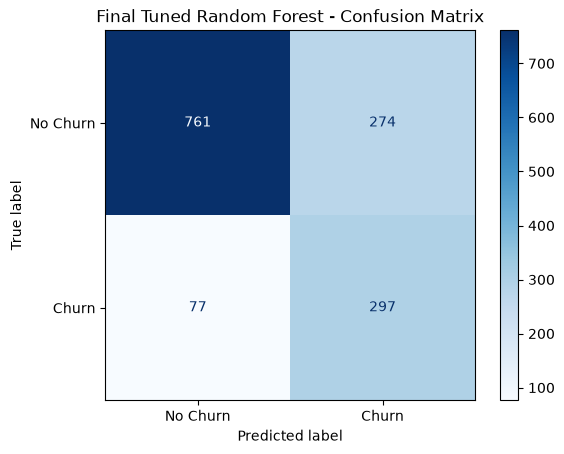

In [71]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_test_rf_tuned,
    display_labels=["No Churn", "Churn"],
    cmap="Blues"
)

plt.title("Final Tuned Random Forest - Confusion Matrix")
plt.show()

## Threshold Optimization

### Evaluating Different Classification Thresholds

### Why Use Cross-Validated Predictions?

To select a classification threshold, we need probabilities that represent how the model performs on unseen customers.

Using:

```python
best_rf_pipeline.predict_proba(X_train)

In [72]:
from sklearn.model_selection import cross_val_predict

y_proba_cv=cross_val_predict(
    best_rf_pipeline,
    X_train, y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:,1]

In [73]:
thresholds=[0.3,0.35,0.4,0.45,0.5,0.55,0.6,0.65]
threshold_results=[]
for threshold in thresholds:
    y_pred_threshold = (y_proba_cv >= threshold).astype(int)
    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_train, y_pred_threshold),
        "Recall": recall_score(y_train, y_pred_threshold),
        "F1-score": f1_score(y_train, y_pred_threshold)
    })
threshold_results_df=pd.DataFrame(threshold_results).round(4)
threshold_results_df.sort_values(by="Recall",ascending=False)

,Threshold,Precision,Recall,F1-score
0,0.30,0.4321,0.9157,0.5872
1,0.35,0.4551,0.8923,0.6028
2,0.40,0.4764,0.8629,0.6138
3,0.45,0.5039,0.8314,0.6275
4,0.50,0.5311,0.7933,0.6363
5,0.55,0.5523,0.7411,0.6330
6,0.60,0.5807,0.6789,0.6260
7,0.65,0.6230,0.6167,0.6198


### Threshold Selection

Different classification thresholds were evaluated using out-of-fold predictions from the training data.

Lower thresholds achieved higher recall but generated more false-positive churn alerts. Higher thresholds improved precision but missed more customers who actually churned.

The highest F1-score was achieved at the default threshold of `0.50`:

- Precision: 53.11%
- Recall: 79.33%
- F1-score: 63.63%

Therefore, `0.50` was selected because it provided the best overall balance between precision and recall.

A different threshold may be selected in production if the company provides the monetary cost of losing a customer and the cost of a retention offer.

##  Customer Risk Segmentation

### Churn Probability and Risk Levels

In [74]:
selected_threshold=0.5
final_predictions=(y_proba_test_rf_tuned >= selected_threshold).astype(int)
customer_results = pd.DataFrame({
    "Customer ID": id_test.values,
    "Churn Probability": y_proba_test_rf_tuned,
    "Predicted Churn": final_predictions,
    "Actual Churn": y_test.values
})


In [75]:
customer_results["Risk Level"]=pd.cut(
    customer_results["Churn Probability"],
    bins=[0,0.30,0.60,1],
    labels=["Low","Medium","High"],
    include_lowest=True
)


In [76]:
customer_results=customer_results.sort_values(by="Churn Probability",ascending=False)
customer_results["Churn Probability"]=(customer_results["Churn Probability"]*100).round(2)
customer_results.tail(10)

,Customer ID,Churn Probability,Predicted Churn,Actual Churn,Risk Level
354,0402-OAMEN,1.16,0,0,Low
482,1555-HAPSU,1.15,0,0,Low
271,3836-FZSDJ,1.14,0,0,Low
664,3642-BYHDO,1.12,0,0,Low
708,8735-SDUFN,1.09,0,0,Low
721,2236-HILPA,1.09,0,0,Low
1344,1927-QEWMY,1.08,0,0,Low
1059,2346-LOCWC,1.07,0,0,Low
70,8224-KDLKN,0.94,0,0,Low
655,1403-GYAFU,0.86,0,0,Low


##  Model Explainability with SHAP

SHAP is used to explain how each feature affects the model's predictions.

It helps answer two questions:

1. Which features have the greatest overall influence on customer churn?
2. Why did the model assign a specific churn probability to an individual customer?

A positive SHAP value pushes the prediction toward churn, while a negative SHAP value pushes the prediction toward no churn.

In [77]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.


In [78]:
import shap

In [79]:
final_preprocessor=best_rf_pipeline.named_steps["preprocessor"]
final_model=best_rf_pipeline.named_steps["model"]
X_test_transformed=final_preprocessor.transform(X_test)


In [82]:
if hasattr(X_test_transformed,"toarray"):
    X_test_transformed=X_test_transformed.toarray()
feature_names=final_preprocessor.get_feature_names_out()

In [84]:
X_test_shap=pd.DataFrame(
    X_test_transformed,
    columns=feature_names,
    index=X_test.index
)
X_test_shap.head()

,num__SeniorCitizen,num__tenure,num__MonthlyCharges,num__TotalCharges,cat__gender_Female,cat__gender_Male,cat__Partner_No,cat__Partner_Yes,cat__Dependents_No,cat__Dependents_Yes,...,cat__StreamingMovies_Yes,cat__Contract_Month-to-month,cat__Contract_One year,cat__Contract_Two year,cat__PaperlessBilling_No,cat__PaperlessBilling_Yes,cat__PaymentMethod_Bank transfer (automatic),cat__PaymentMethod_Credit card (automatic),cat__PaymentMethod_Electronic check,cat__PaymentMethod_Mailed check
437,-0.441773,1.608483,1.629976,2.706828,0.0,1.0,0.0,1.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
2280,2.263606,-0.996684,1.168725,-0.610260,1.0,0.0,1.0,0.0,1.0,0.0,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
2235,-0.441773,0.346606,0.445324,0.400116,1.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4460,-0.441773,-0.589626,0.440347,-0.364451,0.0,1.0,0.0,1.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3761,-0.441773,1.608483,0.588013,1.588421,1.0,0.0,0.0,1.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0


### Calculating SHAP Values

SHAP values measure how much each feature pushes a customer's prediction toward churn or toward no churn.

- A positive SHAP value increases the predicted churn probability.
- A negative SHAP value decreases the predicted churn probability.
- A larger absolute SHAP value means that the feature had a stronger effect.

In [87]:
explainer = shap.TreeExplainer(final_model)
shap_values_raw=explainer.shap_values(X_test_shap)

In [90]:
if isinstance (shap_values_raw,list):
    churn_shap_values =shap_values_raw[1]
elif np.array(shap_values_raw).ndim==3:
    churn_shap_values=np.array(shap_values_raw)[:,:,1]
else:
    churn_shap_values=np.array(shap_values_raw)

In [91]:
print("X_test SHAP shape:", X_test_shap.shape)
print("SHAP values shape:", churn_shap_values.shape)

X_test SHAP shape: (1409, 45)
SHAP values shape: (1409, 45)


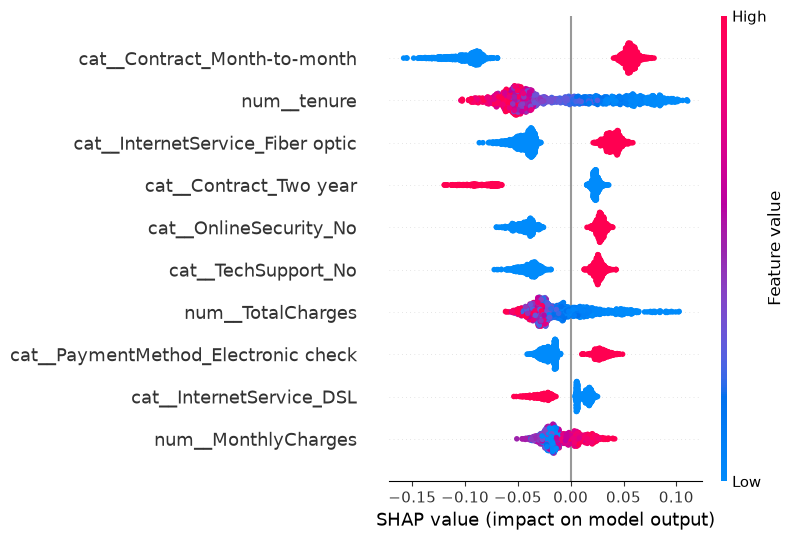

In [98]:
shap.summary_plot(
    churn_shap_values,
    X_test_shap,
  #  plot_type="bar",
    max_display=10
)

In [94]:
shap_values_df = pd.DataFrame(
    churn_shap_values,
    columns=feature_names,
    index=X_test.index
)

shap_values_df.head()

,num__SeniorCitizen,num__tenure,num__MonthlyCharges,num__TotalCharges,cat__gender_Female,cat__gender_Male,cat__Partner_No,cat__Partner_Yes,cat__Dependents_No,cat__Dependents_Yes,...,cat__StreamingMovies_Yes,cat__Contract_Month-to-month,cat__Contract_One year,cat__Contract_Two year,cat__PaperlessBilling_No,cat__PaperlessBilling_Yes,cat__PaymentMethod_Bank transfer (automatic),cat__PaymentMethod_Credit card (automatic),cat__PaymentMethod_Electronic check,cat__PaymentMethod_Mailed check
437,-0.001262,-0.085363,0.004269,-0.045682,0.000941,0.000021,-0.003939,-0.003884,-0.010271,-0.008764,...,0.003918,-0.099258,-0.006808,-0.099875,0.003071,0.003468,-0.001522,-0.010320,-0.016299,0.000217
2280,0.008316,0.054629,0.024773,0.015951,0.001950,0.002575,0.001378,0.001794,0.002974,0.002497,...,0.004485,0.058791,0.006536,0.027529,0.006111,0.005472,0.001436,-0.011764,-0.021990,0.001399
2235,-0.002497,-0.038858,-0.011312,-0.026454,-0.002040,-0.003720,-0.002296,-0.002000,-0.005815,-0.004086,...,-0.012263,-0.104674,-0.027052,0.022952,0.002794,0.002839,0.002995,-0.006478,-0.024030,-0.000003
4460,-0.001811,0.005097,-0.008893,-0.018259,-0.003613,-0.003915,-0.001432,-0.000969,0.001816,0.000835,...,-0.004965,0.059043,0.008533,0.024201,-0.022905,-0.024167,0.002635,0.002482,0.033497,0.000142
3761,-0.002773,-0.070701,-0.012693,-0.030848,-0.000727,-0.001695,-0.002394,-0.003023,0.001577,0.001769,...,0.003849,-0.100604,-0.004344,-0.090829,0.004533,0.004211,0.000367,-0.009520,-0.021283,0.000242


In [95]:
highest_risk_id= customer_results.iloc[0]["Customer ID"]
highest_risk_id

'0295-PPHDO'

In [96]:
customer_position= np.where(
    id_test.values==highest_risk_id
)[0][0]
customer_position

np.int64(1221)

In [97]:
customer_shap = pd.DataFrame({
    "Feature": feature_names,
    "SHAP Value": churn_shap_values[customer_position]
})

customer_shap = customer_shap.sort_values(
    by="SHAP Value",
    ascending=False
)

customer_shap.head(10)

,Feature,SHAP Value
1,num__tenure,0.067883
36,cat__Contract_Month-to-month,0.050862
16,cat__InternetService_Fiber optic,0.037903
3,num__TotalCharges,0.034453
27,cat__TechSupport_No,0.026802
18,cat__OnlineSecurity_No,0.026318
43,cat__PaymentMethod_Electronic check,0.022960
38,cat__Contract_Two year,0.022353
15,cat__InternetService_DSL,0.014987
2,num__MonthlyCharges,0.010543


##  Testing the Pipeline on a New Customer

The final pipeline is tested on a new customer's raw data to confirm that preprocessing, encoding, scaling, and prediction work automatically.

In [104]:
new_customer = pd.DataFrame([{
    "gender": "Female",
    "SeniorCitizen": 0,
    "Partner": "No",
    "Dependents": "No",
    "tenure": 3,
    "PhoneService": "Yes",
    "MultipleLines": "No",
    "InternetService": "Fiber optic",
    "OnlineSecurity": "No",
    "OnlineBackup": "No",
    "DeviceProtection": "No",
    "TechSupport": "No",
    "StreamingTV": "Yes",
    "StreamingMovies": "Yes",
    "Contract": "Month-to-month",
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check",
    "MonthlyCharges": 95.50,
    "TotalCharges": 286.50
}])

new_customer

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,No,No,3,Yes,No,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,95.5,286.5


In [106]:
new_customer_probability=best_rf_pipeline.predict_proba(new_customer)[0,1]
new_customer_probability

np.float64(0.8813115233642781)

In [107]:
selected_threshold=0.5
new_customer_prediction=(new_customer_probability>=selected_threshold).astype(int)
if new_customer_probability < 0.30:
    new_customer_risk = "Low"

elif new_customer_probability < 0.60:
    new_customer_risk = "Medium"

else:
    new_customer_risk = "High"

In [109]:
print(
    "Churn Probability:",
    round(new_customer_probability * 100, 2), "%"
)

print("Predicted Churn:", new_customer_prediction)
print("Risk Level:", new_customer_risk)

Churn Probability: 88.13 %
Predicted Churn: 1
Risk Level: High


##  Saving the Final Pipeline

The trained pipeline is saved so it can be loaded later for deployment without repeating data preprocessing or model training.

In [110]:
import joblib
model_package = {
    "pipeline": best_rf_pipeline,
    "threshold": selected_threshold,
    "low_risk_limit": 0.30,
    "high_risk_limit": 0.60,
    "feature_columns": X.columns.tolist()
}

In [111]:
joblib.dump(
    model_package,
    "customer_churn_model.joblib"
)

['customer_churn_model.joblib']

In [112]:
loaded_package = joblib.load(
    "customer_churn_model.joblib"
)
loaded_pipeline = loaded_package["pipeline"]
loaded_threshold = loaded_package["threshold"]

In [113]:
loaded_probability = loaded_pipeline.predict_proba(
    new_customer
)[0, 1]

loaded_prediction = int(
    loaded_probability >= loaded_threshold
)

print(
    "Loaded model probability:",
    round(loaded_probability * 100, 2),
    "%"
)

print("Loaded model prediction:", loaded_prediction)

Loaded model probability: 88.13 %
Loaded model prediction: 1


##  Project Conclusion

This project developed an end-to-end machine learning pipeline for predicting customer churn.

The dataset was cleaned and analyzed to identify the main patterns associated with customer churn. Categorical features were encoded using One-Hot Encoding, while numerical features were scaled inside a preprocessing pipeline.

Three classification models were evaluated:

- Logistic Regression
- Random Forest
- XGBoost

Cross-validation showed that the models produced relatively similar results. Logistic Regression achieved the highest churn recall, while the tuned Random Forest achieved the best F1-score and ROC-AUC.

The original Random Forest showed strong overfitting. RandomizedSearchCV was therefore used to control tree complexity and improve its ability to generalize to unseen customers.

The tuned Random Forest was selected as the final model because it provided the best overall balance between precision and recall.

The default threshold of `0.50` achieved the highest cross-validation F1-score and was therefore retained.

The final pipeline automatically performs:

- Missing-value handling
- Numerical scaling
- One-Hot Encoding
- Churn probability prediction
- Final churn classification

The model was successfully tested on a new customer and saved using `joblib`, making it ready for a basic deployment.

Future improvements may include:

- Probability calibration
- Business cost-based threshold selection
- Customer retention actions
- Priority scoring
- Bulk CSV prediction
- SHAP explanations in the user interface
- API and dashboard deployment